In [1]:
# as easy as loading using prior localization code

from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd
from prior_localization.prepare_data import prepare_widefield, prepare_pupil
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from ibl_info.prepare_data_pid import get_new_cinc_intervals
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl
from tqdm import tqdm
from glob import glob
import re
import concurrent.futures
import pickle as pkl
import time
from one.api import ONE
import pandas as pd
from tqdm import tqdm
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ibl_info.utils import check_config, compute_animal_stats
from scipy.ndimage import convolve1d
import traceback
from scipy.stats import zscore

config = check_config()

In [2]:
pupil_csv_larger = pd.read_csv("../data/generated/pupil_data/pupil_stats_largerinterval.csv")
pupil_csv_smaller = pd.read_csv("../data/generated/pupil_data/pupil_stats_smallerinterval.csv")

In [51]:
def process_csv(df, masked=True):
    df_ = df.copy()
    df_ = df_[~np.isnan(df_["pupil_z"])]
    df_["signed_contrast"] = df_["contrastLeft"].fillna(0) - df_["contrastRight"].fillna(0)
    df_["difficulty"] = df_["signed_contrast"].abs()
    df_["feedback_binary"] = df_["feedbackType"].apply(lambda x: 1 if x == 1 else 0)
    mask = df_["signed_contrast"] == 0
    if masked:
        df_ = df_[~mask]
    return df_

In [52]:
larger_df = process_csv(pupil_csv_larger, False)
smaller_df = process_csv(pupil_csv_smaller, False)

In [18]:
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

In [19]:
model = smf.logit("feedback_binary ~ pupil_z + difficulty", data=larger_df)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.314235
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:        feedback_binary   No. Observations:                57441
Model:                          Logit   Df Residuals:                    57438
Method:                           MLE   Df Model:                            2
Date:                Wed, 18 Feb 2026   Pseudo R-squ.:                  0.1041
Time:                        11:37:02   Log-Likelihood:                -18050.
converged:                       True   LL-Null:                       -20147.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1283      0.021     53.904      0.000       1.087       1.169
pupil_z       -0.0338      0.

In [20]:
model = smf.logit("feedback_binary ~ pupil_z + difficulty", data=smaller_df)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.314235
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:        feedback_binary   No. Observations:                57439
Model:                          Logit   Df Residuals:                    57436
Method:                           MLE   Df Model:                            2
Date:                Wed, 18 Feb 2026   Pseudo R-squ.:                  0.1041
Time:                        11:37:03   Log-Likelihood:                -18049.
converged:                       True   LL-Null:                       -20146.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1283      0.021     53.903      0.000       1.087       1.169
pupil_z       -0.0359      0.

In [56]:
difficulty_order = np.asarray([1.0, 0.25, 0.125, 0.0625, 0])[::-1]

In [57]:
larger_df["difficulty_cat"] = pd.Categorical(
    larger_df["difficulty"], categories=difficulty_order, ordered=True
)
smaller_df["difficulty_cat"] = pd.Categorical(
    smaller_df["difficulty"], categories=difficulty_order, ordered=True
)

<Axes: xlabel='difficulty_cat', ylabel='pupil_z'>

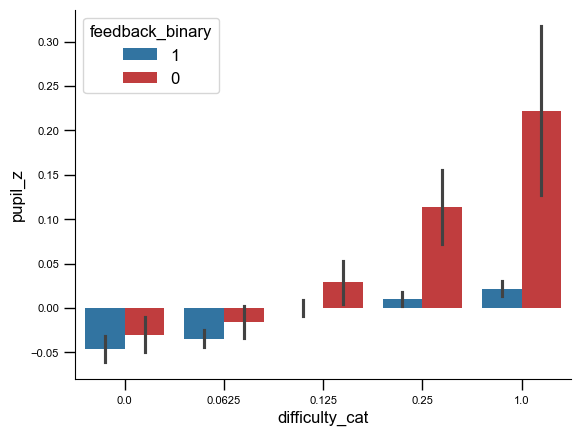

In [58]:
sns.barplot(
    data=larger_df,
    x="difficulty_cat",
    y="pupil_z",
    hue="feedback_binary",
    hue_order=[1, 0],
    palette={1: "tab:blue", 0: "tab:red"},
    errorbar="se",
)

<Axes: xlabel='difficulty_cat', ylabel='pupil_z'>

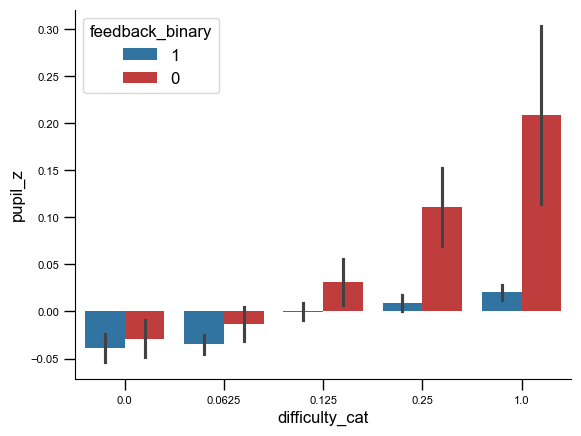

In [59]:
sns.barplot(
    data=smaller_df,
    x="difficulty_cat",
    y="pupil_z",
    hue="feedback_binary",
    hue_order=[1, 0],
    palette={1: "tab:blue", 0: "tab:red"},
    errorbar="se",
)